# 🛑 Stationarity & Differencing

## 1. What is Stationarity?
In time series forecasting (specifically ARIMA), we generally assume that the data is **Stationary**.

**Definition:**
A time series is stationary if its statistical properties do **not** change over time. It has:
1.  **Constant Mean:** The average doesn't drift up or down (No Trend).
2.  **Constant Variance:** The "spread" or volatility is consistent (No funneling).
3.  **Constant Covariance:** The relationship between observations depends only on the time lag, not on the specific time $t$.



**Why do we need it?**
Most statistical models (like Linear Regression or ARIMA) are essentially linear equations. They assume the "rules" of the data structure are constant. If the mean is constantly increasing (a trend), the standard math breaks down.

> **Analogy:** Imagine trying to predict the height of a bouncing ball.
> * *Non-Stationary:* The ball is on an elevator moving up. It's hard to predict the absolute height because the floor keeps moving.
> * *Stationary:* The ball is bouncing on a solid floor. The floor is fixed, so predicting the bounce is much easier.

---

## 2. Differencing (The Fix)
If data is not stationary (e.g., it has a trend), we use **Differencing** to stabilize it. Differencing is simply subtracting the previous value from the current value.

### A. First-Order Differencing ($d=1$)
This is the most common method. It removes a **Linear Trend** (constant growth).
* **Math:** $y'_t = y_t - y_{t-1}$
* **Interpretation:** Instead of looking at the *Price* of a stock, you look at the *Daily Change* in price.
* **Result:** The mean becomes constant (usually centered around 0).

### B. Second-Order Differencing ($d=2$)
Sometimes, the first difference is still not stationary because the trend itself is changing (accelerating or decelerating). This removes **Curvature** (Quadratic Trend).
* **Math:** $y''_t = y'_t - y'_{t-1}$ (The difference of the differences)
* **Usage:** Rare in practice. If you need this, your data is likely exponential or very unstable.

### C. Seasonal Differencing
This removes seasonality by subtracting the value from the same season last cycle.
* **Math:** $y'_t = y_t - y_{t-m}$ (where $m$ is the season length, e.g., 12 for months).

---

## 3. The Test: Augmented Dickey-Fuller (ADF)
How do we mathematically prove data is stationary? We use the ADF Test.

* **Null Hypothesis ($H_0$):** The data is **Non-Stationary** (It has a unit root).
* **Alternative Hypothesis ($H_1$):** The data is **Stationary**.

**The Rule:**
* If **p-value < 0.05**: Reject $H_0$. Data is **Stationary**. (Good to go!)
* If **p-value > 0.05**: Fail to reject $H_0$. Data is **Non-Stationary**. (Need to difference).

#### Stationary and Non-Stationary Data:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('samples.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,a,b,c,d
1950-01-01,36,27,0,67
1950-02-01,58,22,3,31
1950-03-01,61,17,5,67
1950-04-01,37,15,8,47
1950-05-01,66,13,8,62


In [4]:
df.shape

(120, 4)

##### Stationary Data:

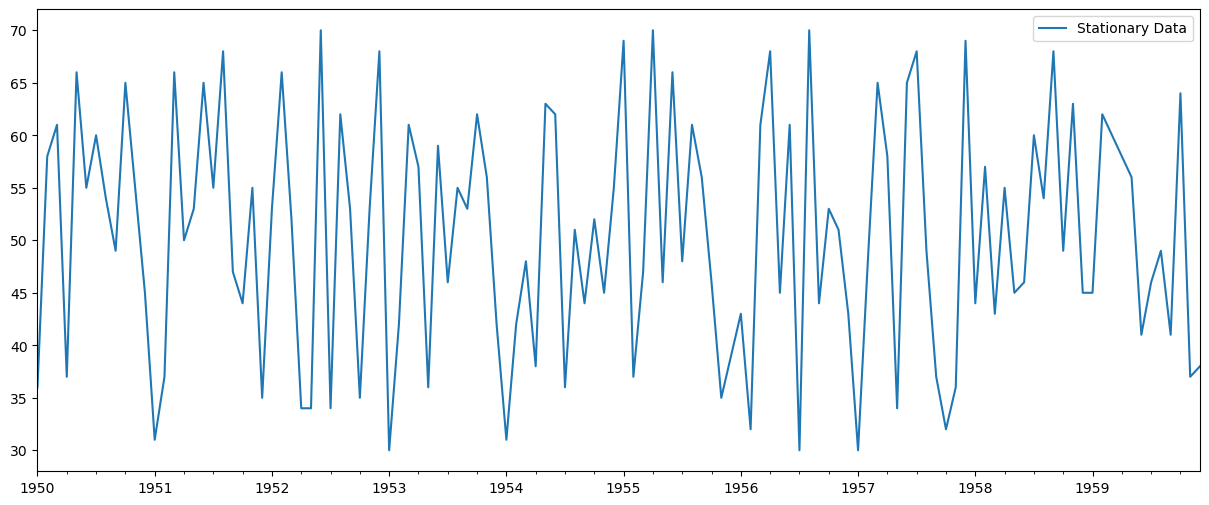

In [6]:
df['a'].plot(kind= 'line', figsize= (15,6), label= 'Stationary Data', legend= True)
plt.show()

##### Non-Stationary Data:

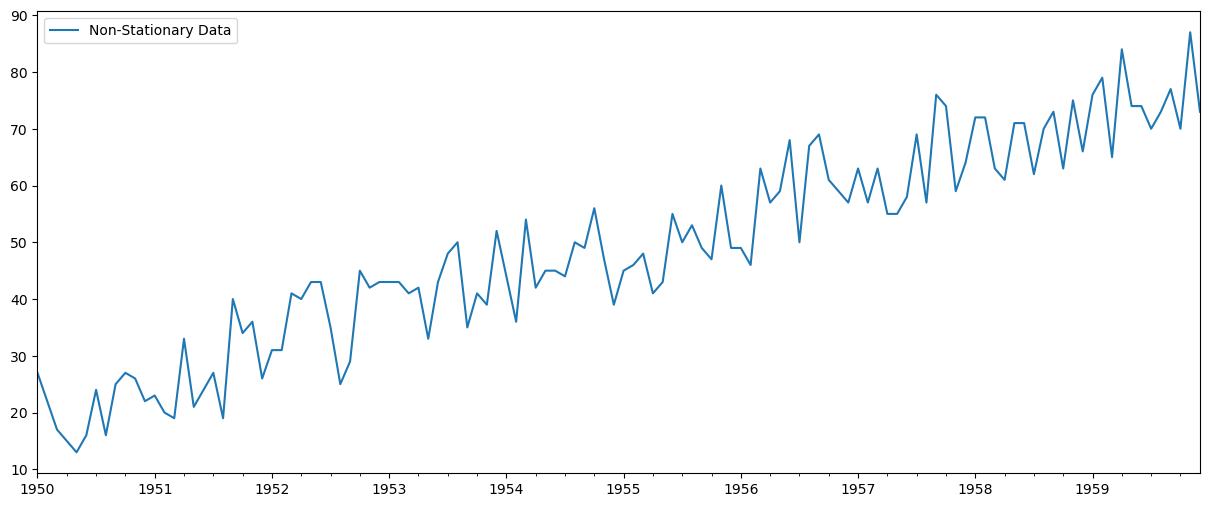

In [7]:
df['b'].plot(kind= 'line', figsize= (15,6), label= 'Non-Stationary Data', legend= True)
plt.show()

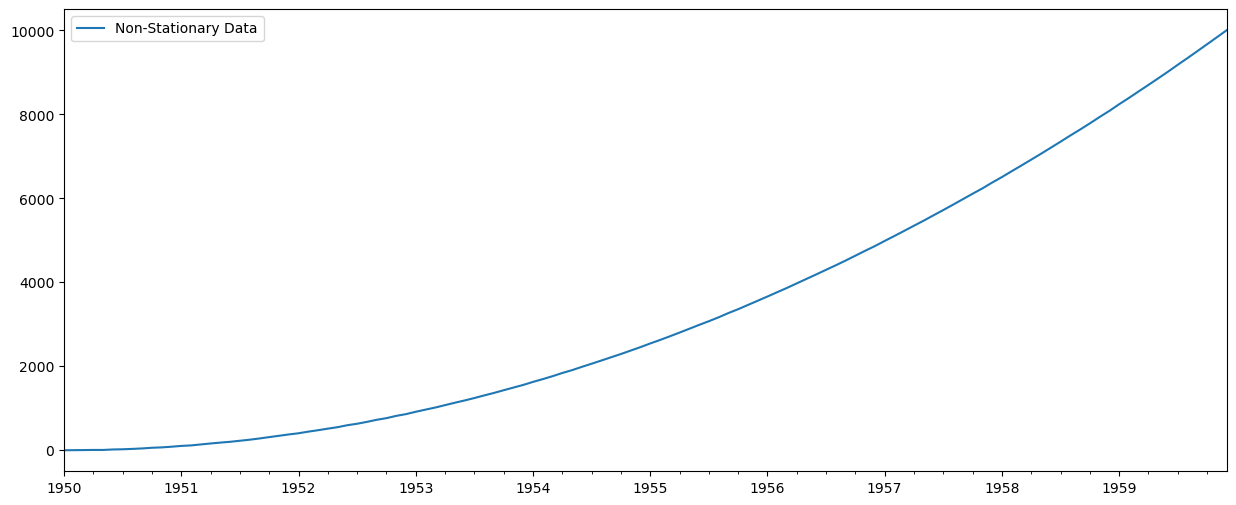

In [8]:
df['c'].plot(kind= 'line', figsize= (15,6), label= 'Non-Stationary Data', legend= True)
plt.show()

#### Differencing:

##### First Order Differencing:

Non-stationary data can be made to look stationary through <em>differencing</em>. A simple method called <em>first order differencing</em> calculates the difference between consecutive observations.

&nbsp;&nbsp;&nbsp;&nbsp;$y^{\prime}_t = y_t - y_{t-1}$

In this way a linear trend is transformed into a horizontal set of values.

`Calculating First Order Differencing on "b" Column:`

In [14]:
df['First_Order_Diff_b'] = df['b'] - df['b'].shift(periods= 1)

In [15]:
df[['b', 'First_Order_Diff_b']].head()

,b,First_Order_Diff_b
1950-01-01,27,NaN
1950-02-01,22,-5.0
1950-03-01,17,-5.0
1950-04-01,15,-2.0
1950-05-01,13,-2.0


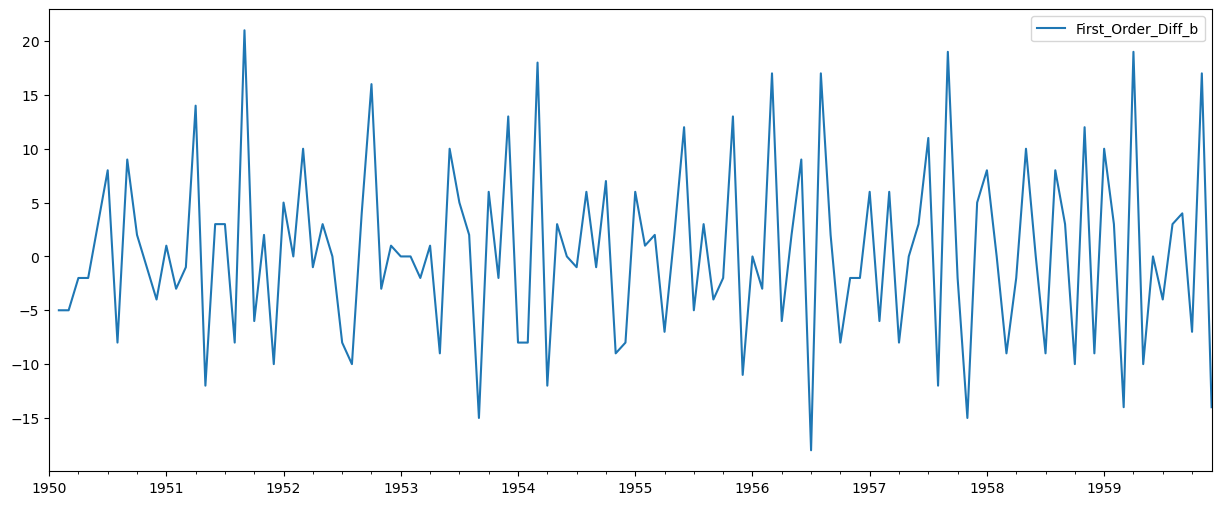

In [16]:
# Plotting 'b' First Order Differencing:

df['First_Order_Diff_b'].plot(kind= 'line', figsize= (15,6), label= 'First_Order_Diff_b', legend= True)
plt.show()

`Same Thing can be Done by Using Pandas diff Method:`

In [17]:
df['First_Order_Diff_b_PD'] = df['b'].diff(periods= 1)

In [18]:
df[['b', 'First_Order_Diff_b', 'First_Order_Diff_b_PD']].head()

,b,First_Order_Diff_b,First_Order_Diff_b_PD
1950-01-01,27,NaN,NaN
1950-02-01,22,-5.0,-5.0
1950-03-01,17,-5.0,-5.0
1950-04-01,15,-2.0,-2.0
1950-05-01,13,-2.0,-2.0


##### Second Order Differencing:

Sometimes the first difference is not enough to attain stationarity, particularly if the trend is not linear. We can difference the already differenced values again to obtain a second order set of values.

&nbsp;&nbsp;&nbsp;&nbsp;$\begin{split}y_{t}^{\prime\prime} &= y_{t}^{\prime} - y_{t-1}^{\prime} \\
&= (y_t - y_{t-1}) - (y_{t-1} - y_{t-2}) \\
&= y_t - 2y_{t-1} + y_{t-2}\end{split}$

`Calculating First Order Differencing on c`:

In [19]:
df['First_Order_Diff_c'] = df['c'].diff(periods= 1)

In [20]:
df.head()

,a,b,c,d,First_Order_Diff_b,First_Order_Diff_b_PD,First_Order_Diff_c
1950-01-01,36,27,0,67,NaN,NaN,NaN
1950-02-01,58,22,3,31,-5.0,-5.0,3.0
1950-03-01,61,17,5,67,-5.0,-5.0,2.0
1950-04-01,37,15,8,47,-2.0,-2.0,3.0
1950-05-01,66,13,8,62,-2.0,-2.0,0.0


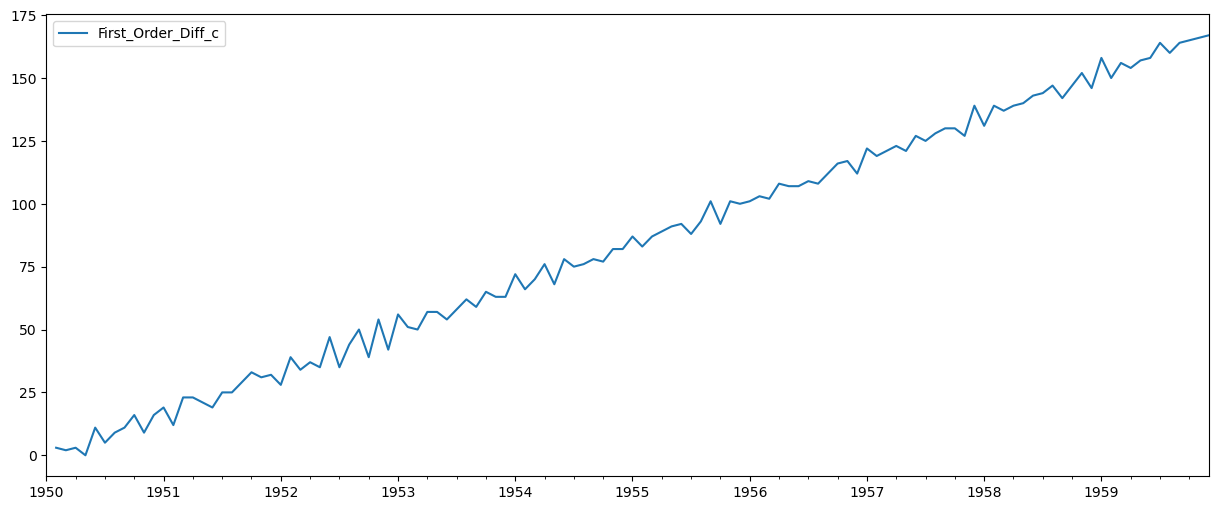

In [21]:
# Plotting 'c' First Order Differencing:

df['First_Order_Diff_c'].plot(kind= 'line', figsize= (15,6), label= 'First_Order_Diff_c', legend= True)
plt.show()

`Second Order Differencing on c`:

In [22]:
df['Second_Order_Diff_c'] = df['c'].diff(periods= 1).diff(periods= 1)

In [23]:
df.head()

,a,b,c,d,First_Order_Diff_b,First_Order_Diff_b_PD,First_Order_Diff_c,Second_Order_Diff_c
1950-01-01,36,27,0,67,NaN,NaN,NaN,NaN
1950-02-01,58,22,3,31,-5.0,-5.0,3.0,NaN
1950-03-01,61,17,5,67,-5.0,-5.0,2.0,-1.0
1950-04-01,37,15,8,47,-2.0,-2.0,3.0,1.0
1950-05-01,66,13,8,62,-2.0,-2.0,0.0,-3.0


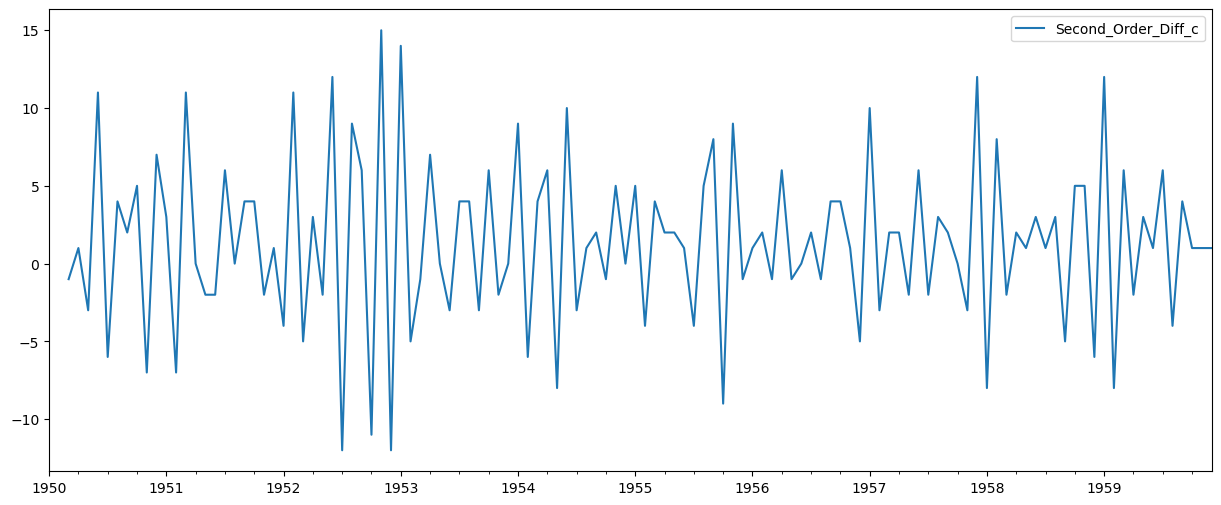

In [24]:
# Plotting 'c' Second Order Differencing:

df['Second_Order_Diff_c'].plot(kind= 'line', figsize= (15,6), label= 'Second_Order_Diff_c', legend= True)
plt.show()